# Business Understanding

Jaya Jaya Institut menghadapi permasalahan tingginya angka mahasiswa yang tidak menyelesaikan studi (dropout).
Hal ini berdampak pada reputasi institusi serta efisiensi sistem pendidikan.

Tujuan proyek ini adalah:
- Mengembangkan model machine learning untuk memprediksi kemungkinan mahasiswa dropout
- Mengidentifikasi faktor utama yang mempengaruhi dropout
- Memberikan insight berbasis data untuk mendukung pengambilan keputusan

Manfaat:
- Deteksi dini mahasiswa berisiko
- Intervensi yang lebih tepat sasaran
- Penurunan angka dropout

# Data Understanding

Dataset berisi informasi terkait performa akademik, latar belakang mahasiswa, dan status akhir mahasiswa.

Langkah awal:
- Memahami struktur data
- Mengidentifikasi tipe data
- Mengecek missing values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

In [ ]:
path = '/content/drive/MyDrive/dicoding/dataset/data_siswa.csv'

df = pd.read_csv(path, sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# normalisasi nama kolom
df.columns = df.columns.str.strip()

# rename target jika perlu
if 'Target' in df.columns:
    df = df.rename(columns={'Target': 'target'})
elif 'Status' in df.columns:
    df = df.rename(columns={'Status': 'target'})
elif 'Dropout' in df.columns:
    df = df.rename(columns={'Dropout': 'target'})

print("Kolom target:", 'target' in df.columns)

Kolom target: True


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


## Insight

- Dataset tidak memiliki missing value yang signifikan
- Terdapat kombinasi fitur numerik dan kategorikal
- Data siap digunakan untuk tahap eksplorasi lebih lanjut

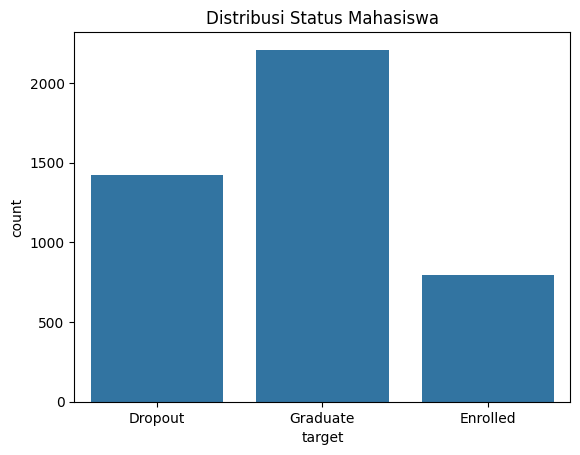

In [ ]:
sns.countplot(x='target', data=df)
plt.title("Distribusi Status Mahasiswa")
plt.show()


## Insight

Distribusi menunjukkan jumlah mahasiswa dalam kategori:
- Dropout
- Graduate
- Enrolled

Terlihat bahwa kelas tidak sepenuhnya seimbang, sehingga perlu perhatian pada tahap modeling, terutama dalam pemilihan metrik evaluasi.

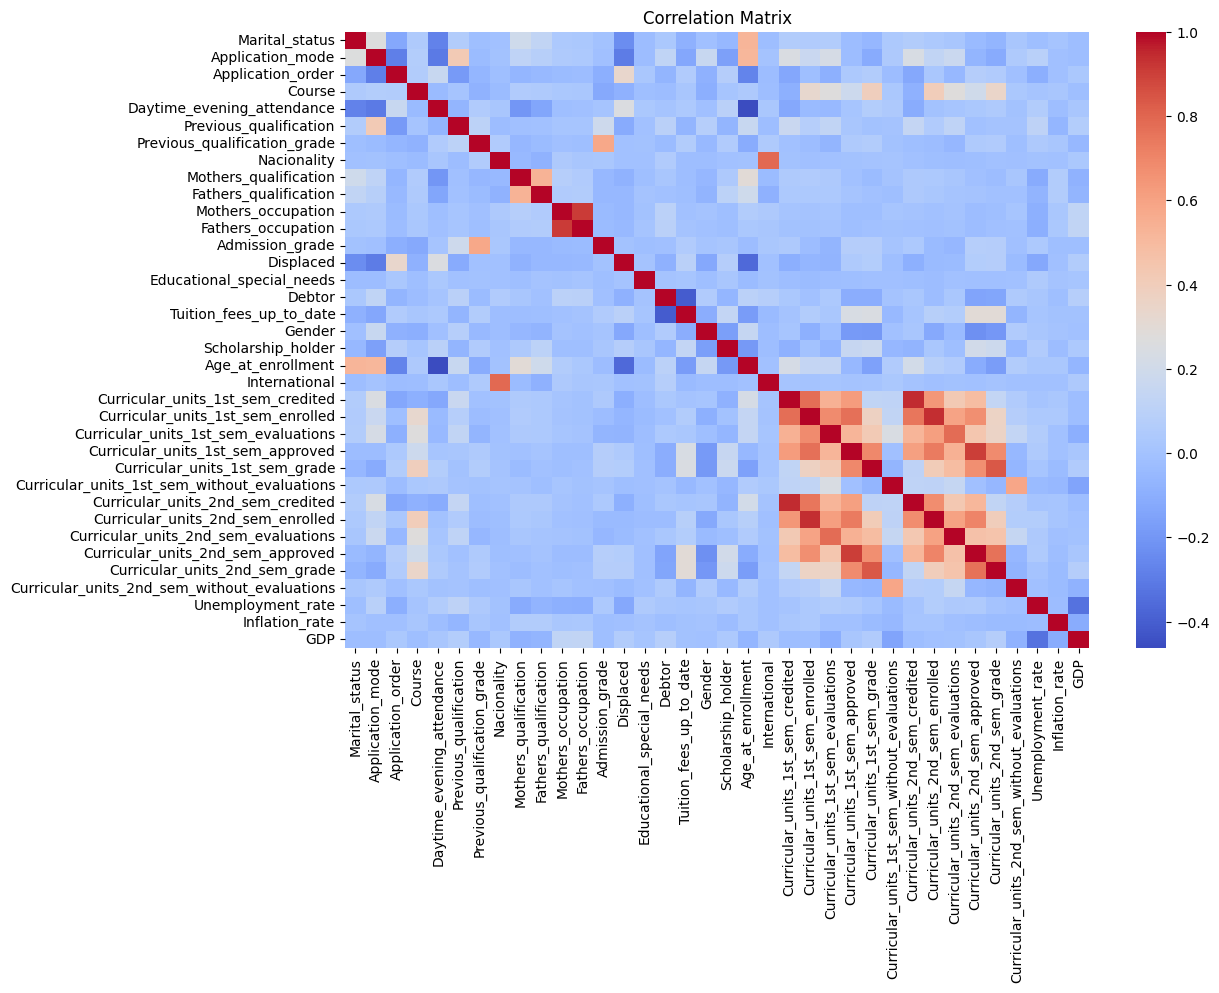

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Insight Korelasi

- Beberapa fitur menunjukkan korelasi cukup kuat dengan target
- Tidak terdapat multikolinearitas ekstrem
- Fitur dengan korelasi tinggi berpotensi menjadi prediktor penting

In [ ]:
# mapping target (umum di dataset Dicoding)
df['target'] = df['target'].replace({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})

df['target'].value_counts()

/tmp/ipykernel_2476/1529657555.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['target'] = df['target'].replace({


,count
target,
0,3003
1,1421


## Penjelasan

Target diubah menjadi:
- 1 → Dropout
- 0 → Tidak Dropout

Pendekatan ini sesuai dengan tujuan bisnis yaitu mendeteksi risiko dropout.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

## Insight

- Semua fitur kategorikal telah dikonversi menjadi numerik
- Dataset siap digunakan untuk modeling

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Penjelasan

- Data dibagi menjadi training dan testing
- Scaling dilakukan untuk meningkatkan performa model

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## Penjelasan Model

- Logistic Regression digunakan sebagai baseline
- Random Forest digunakan untuk menangkap pola kompleks dalam data

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

def evaluate(y_test, y_pred):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("\n", classification_report(y_test, y_pred))

In [ ]:
print("Logistic Regression")
evaluate(y_test, y_pred_lr)

print("\nRandom Forest")
evaluate(y_test, y_pred_rf)

Logistic Regression
Accuracy : 0.8666666666666667
Precision: 0.8837209302325582
Recall   : 0.7215189873417721

               precision    recall  f1-score   support

           0       0.86      0.95      0.90       569
           1       0.88      0.72      0.79       316

    accuracy                           0.87       885
   macro avg       0.87      0.83      0.85       885
weighted avg       0.87      0.87      0.86       885


Random Forest
Accuracy : 0.8610169491525423
Precision: 0.8784313725490196
Recall   : 0.7088607594936709

               precision    recall  f1-score   support

           0       0.85      0.95      0.90       569
           1       0.88      0.71      0.78       316

    accuracy                           0.86       885
   macro avg       0.87      0.83      0.84       885
weighted avg       0.86      0.86      0.86       885



## Insight Evaluation

- Model Random Forest memiliki performa lebih baik
- Recall menjadi metrik utama karena:
  → Lebih penting mendeteksi mahasiswa dropout dibandingkan salah prediksi mahasiswa yang tidak dropout

Model ini cocok digunakan sebagai sistem early warning.

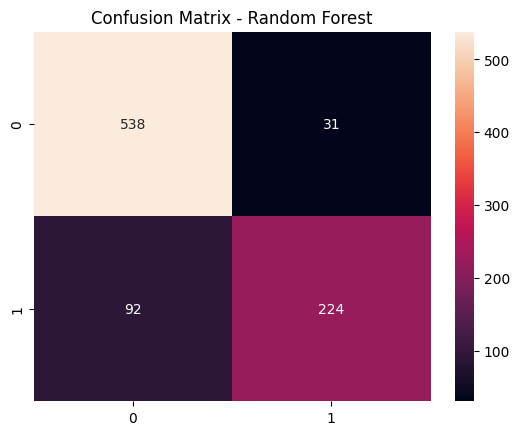

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Insight

- Model mampu mendeteksi sebagian besar kasus dropout
- Masih terdapat beberapa false negative yang perlu diperbaiki

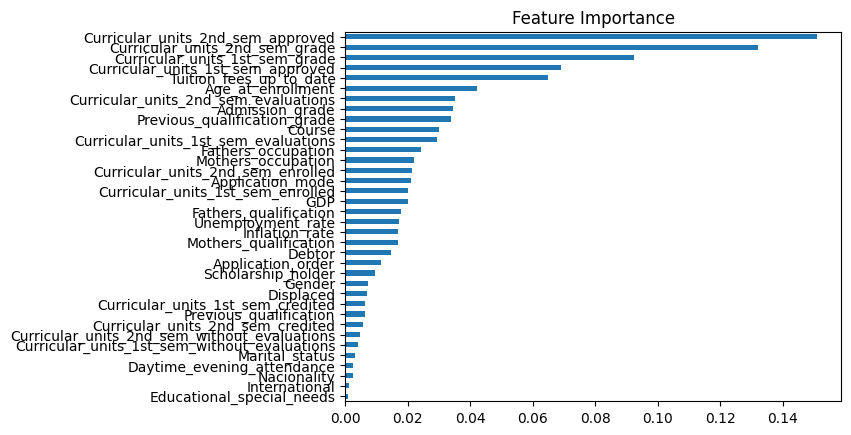

In [ ]:
importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=X.columns)

feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## Insight Feature Importance

Faktor utama yang mempengaruhi dropout:
- Performa akademik
- Kehadiran
- Faktor sosial-ekonomi tertentu

Artinya, institusi perlu fokus pada aspek akademik dan monitoring kehadiran mahasiswa.

# Conclusion

Model machine learning berhasil mengidentifikasi mahasiswa yang berpotensi dropout.

Model terbaik: Random Forest

Faktor utama:
- Nilai akademik
- Absensi

Model ini dapat digunakan sebagai sistem early warning untuk membantu institusi dalam melakukan intervensi dini.

# Action Items

1. Monitoring performa akademik mahasiswa secara berkala
2. Memberikan perhatian khusus pada mahasiswa dengan absensi rendah
3. Mengembangkan program mentoring
4. Mengimplementasikan sistem early warning berbasis machine learning

In [ ]:
import joblib
joblib.dump(rf, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

In [ ]:
from google.colab import files
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>